In [38]:
from sklearn.impute import SimpleImputer, KNNImputer
import numpy as np
import pandas as pd

In [39]:
df = pd.read_excel("uci_concrete_data.xlsx",sheet_name="Sheet1")
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1048.000000,1050.000000,1042.000000,1051.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,281.491308,73.794694,54.148015,181.448016,6.231984,973.076670,773.390569,45.392082,35.907088
std,104.162471,86.110710,63.786094,21.322325,5.944312,77.447901,79.864558,62.353966,16.535634
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,194.680000,0.000000,0.000000,164.900000,0.000000,932.000000,732.050000,14.000000,23.880001
50%,274.000000,22.000000,0.000000,185.000000,6.350000,968.000000,779.320000,28.000000,34.346247
75%,350.000000,142.725000,118.270000,192.000000,10.160000,1029.400000,822.650000,56.000000,46.089490
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [40]:
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
Superplasticizer (component 5)(kg in a m^3 mixture)       0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         0
Age (day)                                                 0
Concrete compressive strength(MPa, megapascals)           0
dtype: int64

### SimpleImputer

In [41]:

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(df)
df_sim_imp = pd.DataFrame(imp.transform(df), columns=df.columns)
#print(df_sim_imp)
#df_sim_imp.isnull().sum()

### Nearest neighbors imputation

In [42]:
imp_near = KNNImputer(n_neighbors=5, weights='distance')
df_near = pd.DataFrame(imp_near.fit_transform(df), columns=df.columns)
#df_near.isnull().sum()
#df_near

### Dropping the rows

In [43]:
df_drop = df.dropna()

#df_drop.isnull().sum()

df_drop.describe()
#df.isnull().sum()
#df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


### Drop duplicates

In [44]:
df_drop.duplicated().sum()
df_drop_dup = df_drop.drop_duplicates()
df_drop_dup.duplicated().sum()

np.int64(0)

### Correlation with respect to compressive strength

In [45]:
df_drop_dup.corr()
# we look to the highest positive and the lowest negative ratio wwith respect to compressive strength

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
Cement (component 1)(kg in a m^3 mixture),1.000000,-0.303301,-0.385618,-0.056583,0.061296,-0.086212,-0.245379,0.086349,0.488283
Blast Furnace Slag (component 2)(kg in a m^3 mixture),-0.303301,1.000000,-0.312342,0.130295,0.019902,-0.277558,-0.289676,-0.042759,0.103370
Fly Ash (component 3)(kg in a m^3 mixture),-0.385618,-0.312342,1.000000,-0.283372,0.414055,-0.026485,0.090229,-0.158940,-0.080648
Water (component 4)(kg in a m^3 mixture),-0.056583,0.130295,-0.283372,1.000000,-0.646875,-0.212495,-0.444888,0.279269,-0.269606
Superplasticizer (component 5)(kg in a m^3 mixture),0.061296,0.019902,0.414055,-0.646875,1.000000,-0.242031,0.207794,-0.194094,0.344225
Coarse Aggregate (component 6)(kg in a m^3 mixture),-0.086212,-0.277558,-0.026485,-0.212495,-0.242031,1.000000,-0.162212,-0.005263,-0.144710
Fine Aggregate (component 7)(kg in a m^3 mixture),-0.245379,-0.289676,0.090229,-0.444888,0.207794,-0.162212,1.000000,-0.156572,-0.186457
Age (day),0.086349,-0.042759,-0.158940,0.279269,-0.194094,-0.005263,-0.156572,1.000000,0.337371
"Concrete compressive strength(MPa, megapascals)",0.488283,0.103370,-0.080648,-0.269606,0.344225,-0.144710,-0.186457,0.337371,1.000000


### Visualization

<Axes: >

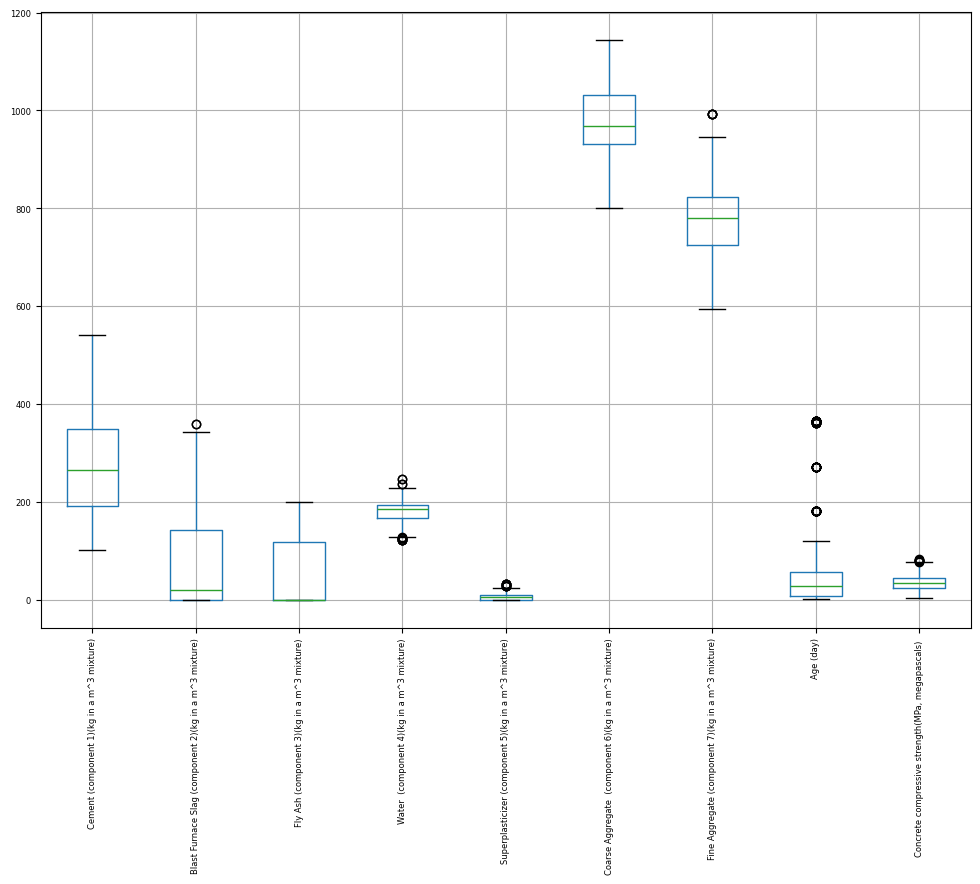

In [46]:
df_drop_dup.boxplot(rot=90, figsize=(12,8), fontsize=6)

### Differentiate input and output data

In [47]:
X = df_drop_dup.iloc[:, 0:8]
Y = df_drop_dup.iloc[:, 8]

### Common seed

In [48]:
from sklearn.model_selection import train_test_split, KFold

In [49]:
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_test, X_val, Y_test, Y_val = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [ ]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.split(X,Y)